In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(data.table)
library(gridExtra)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [2]:
options(repr.plot.width = 21, repr.plot.height = 6)

# MF functions

In the WSC paper, we plot results using low fidelity f1 (exp051 and exp053) and f7 (exp063 and exp064). We discuss qualitatively results from low fidelity f2 with mfGMIAem (exp052) and f4 with mfGMIAem (exp056). 

In [3]:
f <- function(x) {-sin(x) - exp(x / 100) + 10}
x <- seq(0.01, 10, by = 0.01)
y <- f(x)
ymin <- min(y)

In [4]:
fH_2 <- function(x) {10 + 0.01*(x-3)^2} # alternative HF model


f1 <- function(x) {-sin(x) - exp(x / 100) + 10.3 + 0.03*(x-3)^2}
f2 <- function(x) {-sin(x) - exp(x / 100) + 10.3 + 0.01*(x-3)^2}
f3 <- function(x) {-sin(x) - exp(x / 100) + 10.3 + 0.05*(x-3)^2}
f4 <- function(x) {-sin(x) - exp(x / 100) + 10.3}
f5 <- function(x) {-sin(x) - exp(x / 100) + 10.3 - 0.03*(x-3)^2}
f6 <- function(x) {-sin(x) - exp(x / 100) + 10.3 + 0.03*(x-7)^2}
f7 <- function(x) {-sin(x) - exp(x / 100) + 10.3 + 0.07*(x-3)^2}
f8 <- function(x) {-sin(0.5*x+11) - exp((0.5*x+11) / 100) + 10}
f9 <- function(x) {-sin(x+2) - exp((x+2) / 100) + 10}
f10 <- function(x) {10.3 + 0.01*(x-7)^2}
f11 <- function(x) {-sin(x) - exp(x / 100) + 10.3 + 0.03*(x-3)^2}
f12 <- function(x) {-sin(x) - exp(x / 100) + 10.3 + 0.01*(x-3)^2}

yH2 <- fH_2(x)
y1 <- f1(x)
y2 <- f2(x)
y3 <- f3(x)
y4 <- f4(x)
y5 <- f5(x)
y6 <- f6(x)
y7 <- f7(x)
y8 <- f8(x)
y9 <- f9(x)
y10 <- f10(x)
y11 <- f11(x)
y12 <- f12(x)

ymin_alt <- min(yH2)

print(x[which.min(y1)])
print(x[which.min(y2)])
print(x[which.min(y3)])
print(x[which.min(y4)])
print(x[which.min(y5)])
print(x[which.min(y6)])
print(x[which.min(y7)])
print(x[which.min(y8)])
print(x[which.min(y9)])
print(x[which.min(y10)])
print(x[which.min(y11)])
print(x[which.min(y12)])

df_fun <- tibble(
  x = x,
  y = f(x),
  yH2 = fH_2(x),
  y1 = f1(x),
  y2 = f2(x),
  y3 = f3(x),   
  y4 = f4(x),
  y5 = f5(x),
  y6 = f6(x),
  y7 = f7(x),
  y8 = f8(x),
  y9 = f9(x),
  y10 = f10(x),
  y11 = f11(x),
  y12 = f12(x)
) %>%
  pivot_longer(
    cols = starts_with("y"),
    names_to = "func",
    values_to = "y"
  )  %>% group_by(x) %>%
  mutate(
    diff = case_when(
      func == "y11" ~ y - y[func == "yH2"],                  
      TRUE         ~ y - y[func == "y"]
    ) 
  ) %>%
  ungroup() %>%
  mutate(
    exp = case_when(
      func == "y" ~ "050",        
      func == "y1" ~ "051",
      func == "y2" ~ "052",
      func == "y3" ~ "055",      
      func == "y4" ~ "056",
      func == "y5" ~ "057",
      func == "y6" ~ "058",
      func == "y7" ~ "063", 
      func == "y8" ~ "066", 
      func == "y9" ~ "067",  
      func == "y10" ~ "068",         
      func == "y11" ~ "069", 
      func == "y12" ~ "070",         
      TRUE         ~ NA_character_
    )
  )

[1] 1.66
[1] 1.61
[1] 1.71
[1] 7.86
[1] 8.18
[1] 7.82
[1] 1.76
[1] 6.3
[1] 5.86
[1] 7
[1] 1.66
[1] 1.61


# Get data

In [5]:
results_50 <- read.table("./exp050/results/results.txt", header = FALSE)
results_51_0 <- read.table("./exp051/results/results_part_00", header = FALSE)
results_51_1 <- read.table("./exp051/results/results_part_01", header = FALSE)
results_51 <- rbind(results_51_0,results_51_1)
results_52_0 <- read.table("./exp052/results/results_part_00", header = FALSE)
results_52_1 <- read.table("./exp052/results/results_part_01", header = FALSE)
results_52 <- rbind(results_52_0,results_52_1)
results_55 <- read.table("./exp055/results/results.txt", header = FALSE)
results_56 <- read.table("./exp056/results/results.txt", header = FALSE)
results_57 <- read.table("./exp057/results/results.txt", header = FALSE)
results_58 <- read.table("./exp058/results/results.txt", header = FALSE)
results_63 <- read.table("./exp063/results/results.txt", header = FALSE)
results_66 <- read.table("./exp066/results/results.txt", header = FALSE)
results_67 <- read.table("./exp067/results/results.txt", header = FALSE)
results_68 <- read.table("./exp068/results/results.txt", header = FALSE)
results_69 <- read.table("./exp069/results/results.txt", header = FALSE)
results_70 <- read.table("./exp070/results/results.txt", header = FALSE)

In [6]:
colnames_gmia <- c("macrorep",
                       "iteration",
                       "reps_hf",
                       "reps_mf",
                       "cpu",
                       "x",
                       "opt_gap_pkg",
                       "cand_opt_gap_pkg",
                       "lofi",
                       "hifi",
                       "mu",
                       "theta0",
                       "minus_theta0_theta1",
                       "muE")

colnames_mf_gmia_em <- c("macrorep",
                       "iteration",
                       "reps_hf",
                       "reps_mf",
                       "cpu",
                       "x",
                       "opt_gap_pkg",
                       "cand_opt_gap_pkg",
                       "lofi",
                       "hifi",
                       "mu",
                       "theta0",
                       "minus_theta0_theta1",
                       "muE",
                       "theta0E",
                       "minus_theta0E_theta1E")

colnames(results_50) <- colnames_gmia
colnames(results_51) <- colnames_mf_gmia_em
colnames(results_52) <- colnames_mf_gmia_em
colnames(results_55) <- colnames_mf_gmia_em
colnames(results_56) <- colnames_mf_gmia_em
colnames(results_57) <- colnames_mf_gmia_em
colnames(results_58) <- colnames_mf_gmia_em
colnames(results_63) <- colnames_mf_gmia_em
colnames(results_66) <- colnames_mf_gmia_em
colnames(results_67) <- colnames_mf_gmia_em
colnames(results_68) <- colnames_mf_gmia_em
colnames(results_69) <- colnames_mf_gmia_em
colnames(results_70) <- colnames_mf_gmia_em

In [7]:
results_50 <- results_50 %>% mutate(exp="050",alg="GMIA",lf_model=NA) %>% mutate(opt_gap = f(x) - ymin)
results_51 <- results_51 %>% mutate(exp="051",alg="mf-GMIA-em",lf_model=1) %>% mutate(opt_gap = f(x) - ymin)
results_52 <- results_52 %>% mutate(exp="052",alg="mf-GMIA-em",lf_model=2) %>% mutate(opt_gap = f(x) - ymin)
results_55 <- results_55 %>% mutate(exp="055",alg="mf-GMIA-em",lf_model=3) %>% mutate(opt_gap = f(x) - ymin)
results_56 <- results_56 %>% mutate(exp="056",alg="mf-GMIA-em",lf_model=4) %>% mutate(opt_gap = f(x) - ymin)
results_57 <- results_57 %>% mutate(exp="057",alg="mf-GMIA-em",lf_model=5) %>% mutate(opt_gap = f(x) - ymin)
results_58 <- results_58 %>% mutate(exp="058",alg="mf-GMIA-em",lf_model=6) %>% mutate(opt_gap = f(x) - ymin)
results_63 <- results_63 %>% mutate(exp="063",alg="mf-GMIA-em",lf_model=7) %>% mutate(opt_gap = f(x) - ymin)
results_66 <- results_66 %>% mutate(exp="066",alg="mf-GMIA-em",lf_model=8) %>% mutate(opt_gap = f(x) - ymin)
results_67 <- results_67 %>% mutate(exp="067",alg="mf-GMIA-em",lf_model=9) %>% mutate(opt_gap = f(x) - ymin)
results_68 <- results_68 %>% mutate(exp="068",alg="mf-GMIA-em",lf_model=10) %>% mutate(opt_gap = f(x) - ymin)
results_69 <- results_69 %>% mutate(exp="069",alg="mf-GMIA-em",lf_model=1)  %>% mutate(opt_gap = fH_2(x) - ymin_alt)
results_70 <- results_70 %>% mutate(exp="070",alg="mf-GMIA-em",lf_model=2) %>% mutate(opt_gap = f(x) - ymin)

In [8]:
results <- bind_rows(results_50,
                     results_51,
                     results_52,
                     results_55,
                     results_56,
                     results_57,
                     results_58,
                     results_63,
                     results_66,
                     results_67,
                     results_68, 
                     results_69,
                     results_70)

# Helper functions

In [9]:
get_summary_data <- function(df, tmin, mmax){
    df_new <- data.frame(exp = character(), 
                         alg = character(),
                         lf_model = numeric(),
                         macrorep = numeric(),
                         budget = numeric(),
                         opt_gap = numeric())
    for (m in 0:mmax){
        for (t in seq(tmin, 2003.2, by = 100)){
            opt_gap_data <- df %>% filter(macrorep == m, reps_mf <= t)
            opt_gap_data <- opt_gap_data %>% filter(iteration == max(iteration))
            opt_gap_value <- opt_gap_data$opt_gap
            new_row <- data.frame(exp = opt_gap_data$exp, 
                                  alg = opt_gap_data$alg,
                                  lf_model = opt_gap_data$lf_model,
                                  macrorep = m,
                                  budget = t,
                                  opt_gap = opt_gap_value)
            df_new <- rbind(df_new, new_row)
            }
        }
    return(df_new)
    }

In [10]:
plot <- function(df,experiments,title_txt,filename){
    p1 <- ggplot(df_fun %>% filter(exp %in% experiments), aes(x = x, y = y, colour = func)) +
      geom_line(linewidth = 1) +
      labs(
        title = "Multi-fidelity models",
        x = "x",
        y = "y",
        colour = "Function"
      ) +
      theme_bw() +
      theme(
        axis.title   = element_text(size = 18),
        axis.text    = element_text(size = 16),
        legend.title = element_text(size = 18),
        legend.text  = element_text(size = 16),
        plot.title   = element_text(size = 20)
      ) + scale_y_continuous(
        limits = c(7.4, 11.25)
      )

    theta <- df %>%
      filter(exp == experiments[2]) %>%
      pull(theta0E_mean) %>%
      first()
    
    p2 <- ggplot(df_fun %>% filter(exp %in% experiments), aes(x = x, y = diff, colour = func)) +
      geom_line(linewidth = 1) +
      labs(
        title = bquote("Low-fidelity error (" * theta == .(round(theta, 2)) * ")"),
        x = "x",
        y = "y",
        colour = "Function"
      ) +
      theme_bw() +
      theme(
        axis.title   = element_text(size = 18),
        axis.text    = element_text(size = 16),
        legend.title = element_text(size = 18),
        legend.text  = element_text(size = 16),
        plot.title   = element_text(size = 20)
      ) + scale_y_continuous(
        limits = c(-1.5, 2)
      )

    p3 <- ggplot(df %>% filter(exp %in% experiments),
           aes(x = budget,
               y = opt_gap_mean,
               colour = exp,
               fill = exp,
               group = exp)) +
      geom_line() +
      geom_ribbon(
          aes(
            ymin = opt_gap_mean - 2 * std_error,
            ymax = opt_gap_mean + 2 * std_error),
      alpha = 0.15,
      linewidth = 0
    ) +
    geom_line() +
    labs(title = title_txt,
      x = "Simulation budget",
      y = "Optimality gap",
      colour = "Experiment",
      fill = "Experiment"
      ) +
      theme_bw()+
    theme(
      axis.title  = element_text(size = 18),
      axis.text   = element_text(size = 16),
      legend.title = element_text(size = 18),
      legend.text  = element_text(size = 16),
      plot.title   = element_text(size = 20)
    ) + scale_y_continuous(
        limits = c(0, 0.09)
      )
    
    grid.arrange(p1, p2, p3,
             ncol = 3,
             widths = c(10, 10, 10))
    }

# Opt Gap mf-GMIA-em

In [11]:
print('starting')
data_50 <- get_summary_data(results_50,201, 199)
print('done 1/8')
data_51 <- get_summary_data(results_51,201, 199)
print('done 3/8')
data_52 <- get_summary_data(results_52,201.2, 199)
print('done 2/8')
data_55 <- get_summary_data(results_55,201, 199)
print('done 4/8')
data_56 <- get_summary_data(results_56,201, 99)
print('done 5/8')
data_57 <- get_summary_data(results_57,201, 99)
print('done 6/8')
data_58 <- get_summary_data(results_58,201, 99)
print('done 7/8')
data_63 <- get_summary_data(results_63,201, 199)
print('done 8/8')
data_66 <- get_summary_data(results_66,201.2, 199)
print('done 5/8')
data_67 <- get_summary_data(results_67,201.2, 199)
print('done 6/8')
data_68 <- get_summary_data(results_68,201.2, 199)
print('done 7/8')
data_69 <- get_summary_data(results_69,201.2, 199)
print('done 6/8')
data_70 <- get_summary_data(results_70,603.2, 199)
print('done 7/8')

[1] "starting"
[1] "done 1/8"
[1] "done 3/8"
[1] "done 2/8"
[1] "done 4/8"
[1] "done 5/8"
[1] "done 6/8"
[1] "done 7/8"
[1] "done 8/8"
[1] "done 5/8"
[1] "done 6/8"
[1] "done 7/8"
[1] "done 6/8"
[1] "done 7/8"


In [12]:
data_mfGMIAem <- bind_rows(data_50,
                           data_51,
                           data_52,
                           data_55,
                           data_56,                           
                           data_57,
                           data_58,
                           data_63,                           
                           data_66,
                           data_67,
                           data_68,
                           data_69,
                           data_70)

In [13]:
results_thetas <- results %>% filter(exp %in% c("051",
                                                "052",
                                                "055",
                                                "056",
                                                "057",
                                                "058",
                                                "063",
                                                "066","067","068","069","070")) %>% group_by(exp, macrorep, theta0E) %>% summarise(n=n()) %>% 
    group_by(exp) %>% summarise(theta0E_mean=mean(theta0E))

summary_data_mfGMIAem <- data_mfGMIAem %>%
    group_by(exp, alg, lf_model, budget) %>%
        summarise(n=n(),
                  opt_gap_mean = mean(opt_gap),
                  std_error = sd(opt_gap, na.rm = TRUE) / sqrt(n)) %>%
left_join(results_thetas, by = "exp")

`summarise()` has grouped output by 'exp', 'macrorep'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'exp', 'alg', 'lf_model'. You can override using the `.groups` argument.


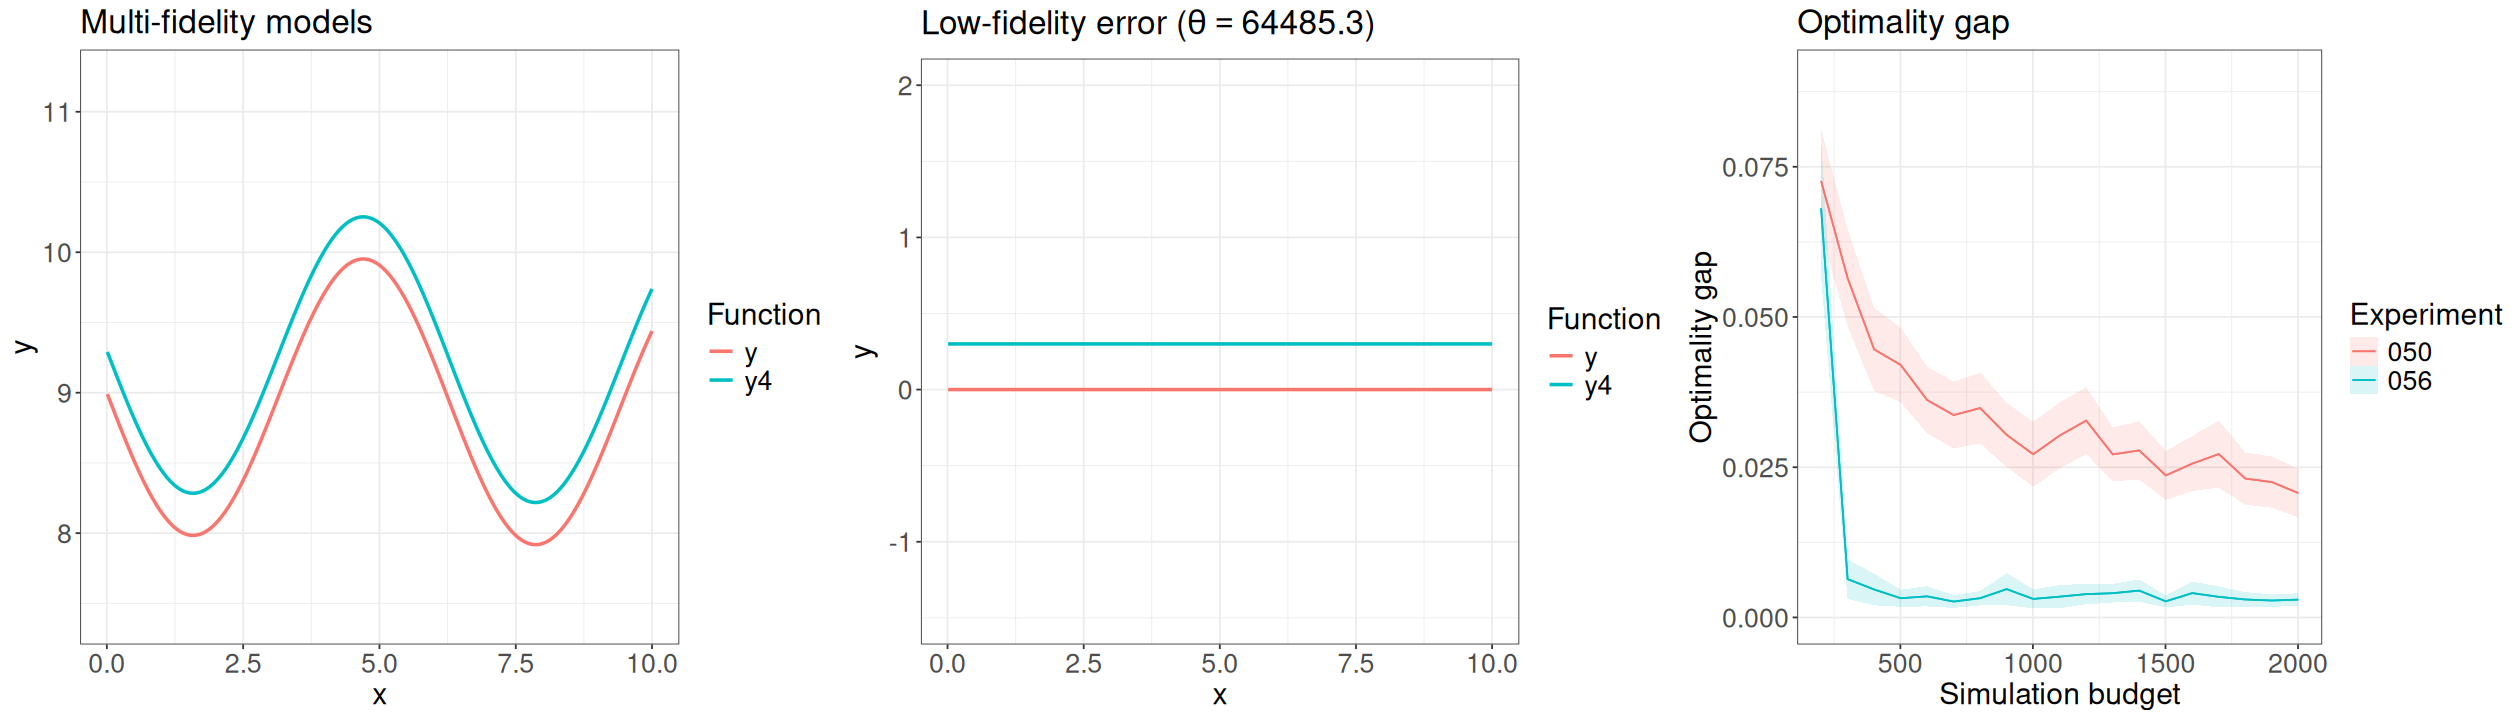

In [19]:
plot(summary_data_mfGMIAem,
     c("050","056"),
     'Optimality gap')

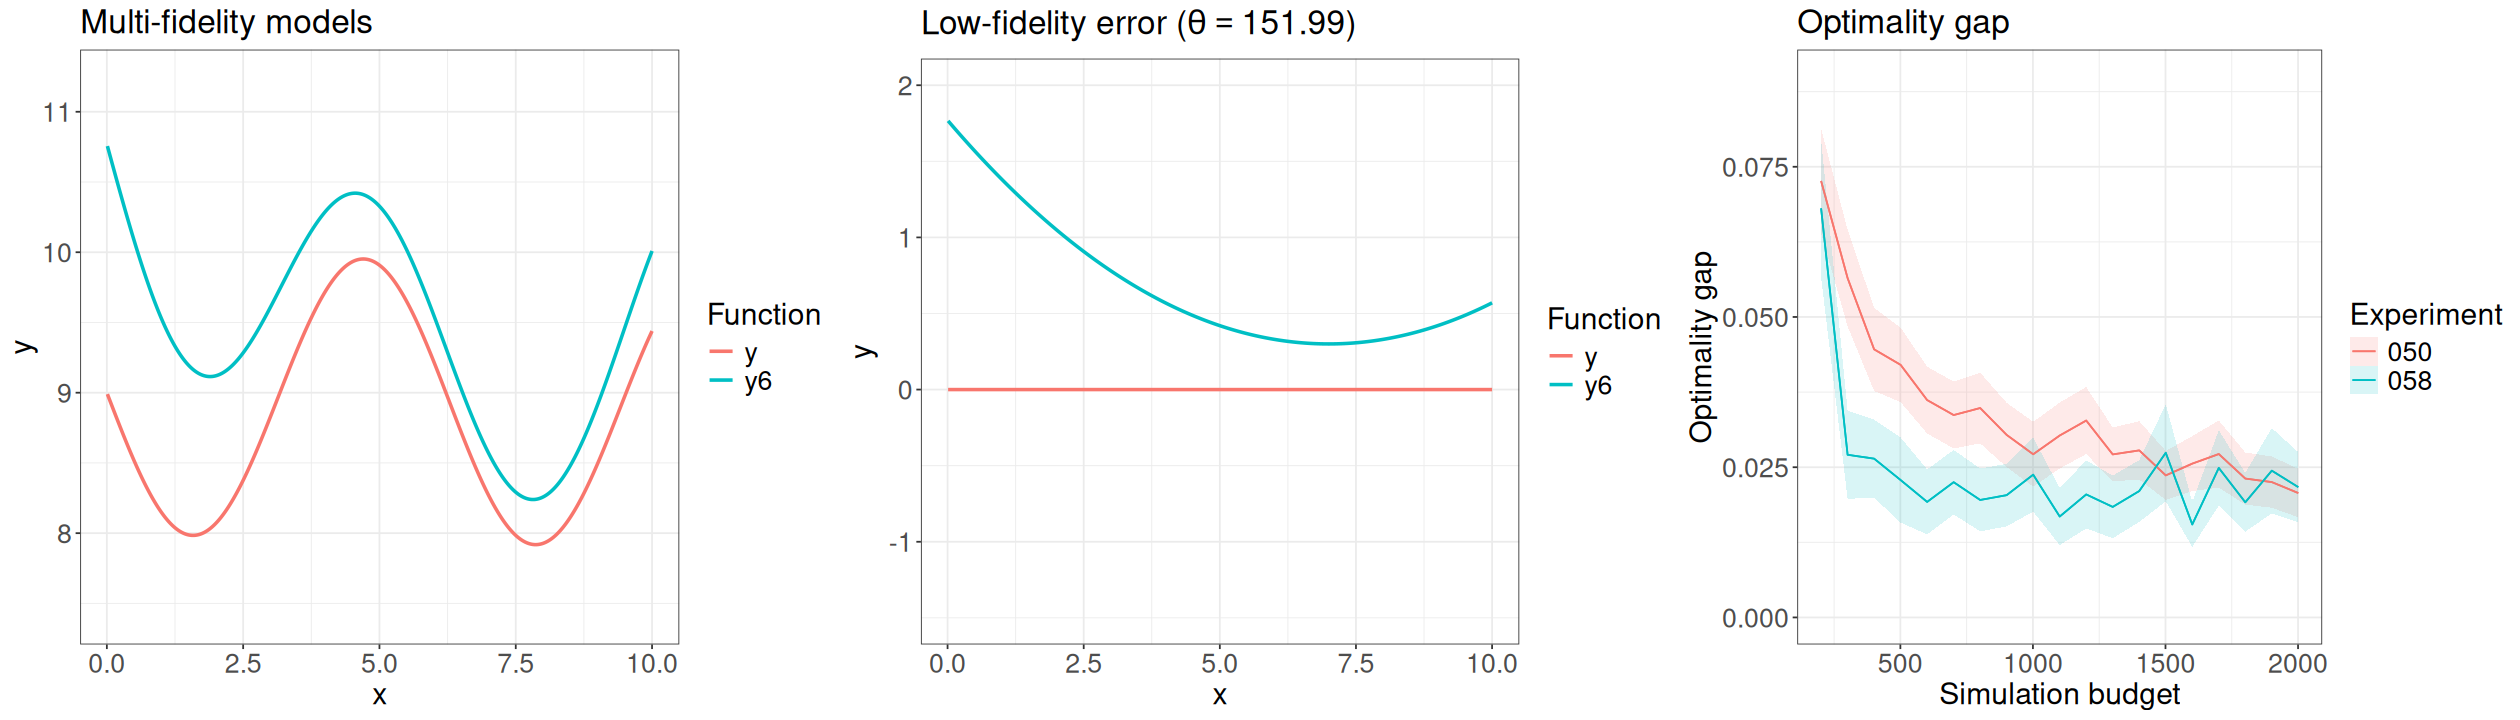

In [15]:
plot(summary_data_mfGMIAem,
     c("050","058"),
     'Optimality gap')

In [16]:
results %>% filter(exp %in% c("050",
                              "051",
                              "052",
                              "055",
                              "056",
                              "057",
                              "058",
                              "063",
                              "066","067","068","069","070")) %>% group_by(exp, macrorep, theta0, theta0E) %>% summarise(n=n()) %>% 
    group_by(exp) %>% summarise(theta0_mean=format(mean(theta0), scientific=FALSE),theta0E_mean=format(mean(theta0E),scientific=FALSE))

`summarise()` has grouped output by 'exp', 'macrorep', 'theta0'. You can override using the `.groups` argument.


exp,theta0_mean,theta0E_mean
<chr>,<chr>,<chr>
050,59.23591,NA
051,59.91466,131.5779
052,58.2311,2024.955
055,63.01475,50.58981
056,59.08091,64485.3
057,60.14269,180.873
058,61.02004,151.9937
063,67.44737,27.79455
066,58.55895,24.30944


# Explore proportion LF

In [17]:
props_LF_51 <- results_51 %>%
  group_by(macrorep) %>%
  summarise(
    prop_LF = mean(lofi == "True")
  ) 
print(mean(props_LF_51$prop_LF))

props_LF_51 <- results_51 %>% filter(iteration < 100) %>%
  group_by(macrorep) %>%
  summarise(
    prop_LF = mean(lofi == "True")
  ) 
print(mean(props_LF_51$prop_LF))

[1] 0.4771325
[1] 0.7318282


In [18]:
props_LF_63 <- results_63 %>% 
  group_by(macrorep) %>%
  summarise(
    prop_LF = mean(lofi == "True")
  ) 
print(mean(props_LF_63$prop_LF))

props_LF_63 <- results_63 %>% filter(iteration < 100) %>%
  group_by(macrorep) %>%
  summarise(
    prop_LF = mean(lofi == "True")
  ) 
print(mean(props_LF_63$prop_LF))

[1] 0.3661278
[1] 0.47336
